In [147]:
# These import statements are correctly written.
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix



In [148]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
print(df.head(5))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [149]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

(569, 30)

In [150]:
print(df.shape)
print(data.target_names)

(569, 30)
['malignant' 'benign']


In [151]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [152]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [153]:
X_train, X_test, y_train, y_test = train_test_split(df, y,train_size=0.8,random_state=42, stratify=y)

In [154]:
selector = SelectKBest(score_func=f_classif, k=5)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

print("Selected feature indices:", selector.get_support(indices=True))

Selected feature indices: [ 2  7 20 22 27]


In [155]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

In [156]:
# #Linear

# svm_lin = SVC(kernel="linear", random_state=42)
# svm_lin.fit(X_train_scaled, y_train)

In [157]:
# y_pred_lin = svm_lin.predict(X_test_scaled)

In [158]:
# accuracy = accuracy_score(y_test, y_pred_lin)
# precision = precision_score(y_test, y_pred_lin)
# recall = recall_score(y_test, y_pred_lin)
# f1 = f1_score(y_test, y_pred_lin)
# cm = confusion_matrix(y_test, y_pred_lin)

# print("Confusion Matrix:\n", cm)
# print(f"Accuracy  : {accuracy:.4f}")
# print(f"Precision : {precision:.4f}")
# print(f"Recall    : {recall:.4f}")
# print(f"F1 Score  : {f1:.4f}")

In [159]:
kernels = {
    "Linear": SVC(kernel="linear", random_state=42),
    "Poly (degree=2)": SVC(kernel="poly", degree=2, random_state=42),
    "Poly (degree=3)": SVC(kernel="poly", degree=3, random_state=42),
    "Poly (degree=4)": SVC(kernel="poly", degree=4, random_state=42),
    "Gaussian (RBF,Gamma - 0.01)": SVC(kernel="rbf", gamma=0.01, random_state=42),
    "Gaussian (RBF),Gamma - 0.1": SVC(kernel="rbf", gamma=0.1, random_state=42),
    "Gaussian (RBF),Gamma - 1.0": SVC(kernel="rbf", gamma=1, random_state=42),
    "Sigmoid_g0.01_c0": SVC(kernel="sigmoid", random_state=42, gamma=0.01, coef0=0),
    "Sigmoid_g0.1_c1": SVC(kernel="sigmoid", random_state=42, gamma=0.1, coef0=1)
}

results = []

for name, model in kernels.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Kernel": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\nKernel: {name}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)


Kernel: Linear
Accuracy  : 0.9474
Precision : 0.9714
Recall    : 0.9444
F1 Score  : 0.9577
Confusion Matrix:
 [[40  2]
 [ 4 68]]

Kernel: Poly (degree=2)
Accuracy  : 0.7895
Precision : 0.7500
Recall    : 1.0000
F1 Score  : 0.8571
Confusion Matrix:
 [[18 24]
 [ 0 72]]

Kernel: Poly (degree=3)
Accuracy  : 0.9123
Precision : 0.8780
Recall    : 1.0000
F1 Score  : 0.9351
Confusion Matrix:
 [[32 10]
 [ 0 72]]

Kernel: Poly (degree=4)
Accuracy  : 0.7895
Precision : 0.7500
Recall    : 1.0000
F1 Score  : 0.8571
Confusion Matrix:
 [[18 24]
 [ 0 72]]

Kernel: Gaussian (RBF,Gamma - 0.01)
Accuracy  : 0.9298
Precision : 0.9324
Recall    : 0.9583
F1 Score  : 0.9452
Confusion Matrix:
 [[37  5]
 [ 3 69]]

Kernel: Gaussian (RBF),Gamma - 0.1
Accuracy  : 0.9386
Precision : 0.9710
Recall    : 0.9306
F1 Score  : 0.9504
Confusion Matrix:
 [[40  2]
 [ 5 67]]

Kernel: Gaussian (RBF),Gamma - 1.0
Accuracy  : 0.9649
Precision : 0.9722
Recall    : 0.9722
F1 Score  : 0.9722
Confusion Matrix:
 [[40  2]
 [ 2 70]]

K

In [160]:
results_df = pd.DataFrame(results)
print(results_df)

                        Kernel  Accuracy  Precision    Recall  F1 Score
0                       Linear  0.947368   0.971429  0.944444  0.957746
1              Poly (degree=2)  0.789474   0.750000  1.000000  0.857143
2              Poly (degree=3)  0.912281   0.878049  1.000000  0.935065
3              Poly (degree=4)  0.789474   0.750000  1.000000  0.857143
4  Gaussian (RBF,Gamma - 0.01)  0.929825   0.932432  0.958333  0.945205
5   Gaussian (RBF),Gamma - 0.1  0.938596   0.971014  0.930556  0.950355
6   Gaussian (RBF),Gamma - 1.0  0.964912   0.972222  0.972222  0.972222
7             Sigmoid_g0.01_c0  0.938596   0.933333  0.972222  0.952381
8              Sigmoid_g0.1_c1  0.929825   0.970588  0.916667  0.942857


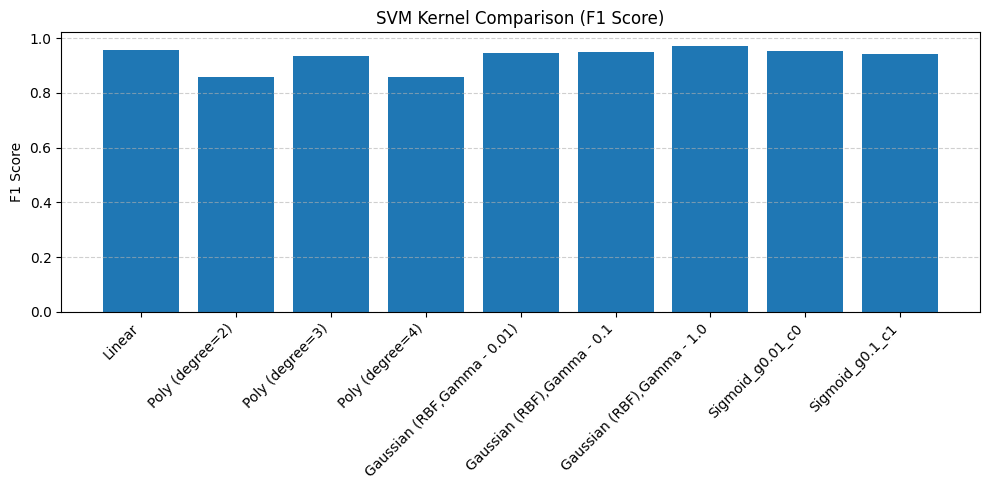

In [161]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Kernel"], results_df["F1 Score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("SVM Kernel Comparison (F1 Score)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


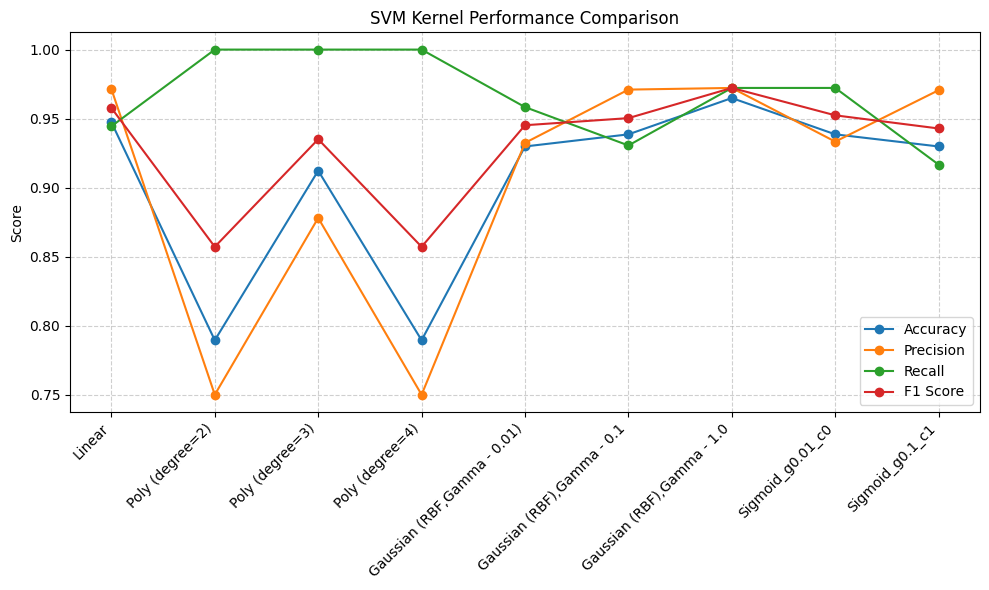

In [162]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(
        results_df["Kernel"],
        results_df[metric],
        marker="o",
        label=metric
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Score")
plt.title("SVM Kernel Performance Comparison")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
